# Imports & Initializations

In [ ]:
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar


DF_MESTA = pd.read_csv(
    'data/slovensko.csv',
    sep=','
)
M = len(DF_MESTA)
SUCET_POPULACIE = DF_MESTA['Population'].sum()
DF_MESTA['Weight'] = DF_MESTA['Population'] / SUCET_POPULACIE

DF_MESTA['geometry'] = [Point(xy) for xy in zip(DF_MESTA['Longitude'], DF_MESTA['Latitude'])]

DF_MESTA = gpd.GeoDataFrame(DF_MESTA, geometry='geometry', crs='EPSG:4326')
DF_MESTA = DF_MESTA.to_crs(epsg=5514)
# DF_MESTA['Points'] = DF_MESTA.geometry.apply(lambda p: [p.x, p.y]).to_numpy()
COORDS = np.column_stack([
    DF_MESTA.geometry.x,
    DF_MESTA.geometry.y,
])


WEIGHTS = DF_MESTA['Weight'].to_numpy()[:, None]

def plot_slovakia(point=None):
    slovakia = gpd.read_file(
        "data/ne_10m_admin_0_countries.zip"
    )

    slovakia = slovakia[slovakia["ISO_A3"] == "SVK"]
    slovakia = slovakia.to_crs(epsg=5514)


    fig, ax = plt.subplots(figsize=(10,8))

    slovakia.plot(
        ax=ax,
        color='whitesmoke',
        edgecolor='black'
    )

    DF_MESTA.plot(
        ax=ax,
        color='red',
        markersize=np.sqrt(DF_MESTA['Population']) / 5,
        alpha=0.7
    )

    if point is not None:
        ax.scatter(point[0], point[1], s=160, color="green", marker="x", zorder=5)

    for x,y,city in zip(DF_MESTA.geometry.x, DF_MESTA.geometry.y, DF_MESTA['City']):
        ax.text(x,y,city, fontsize=8, ha='left', va='bottom')

    ax.set_axis_off()

    plt.tight_layout()
    plt.show()
    

In [2]:
# print(world.columns)
# print(world[["ADMIN", "NAME", "SOVEREIGNT"]].head())
# print(world[world.astype(str).apply(lambda row: row.str.contains("Slovak", case=False).any(), axis=1)])
# minx, miny, maxx, maxy = slovakia.total_bounds
# print(minx, miny, maxx, maxy)

# Uloha a)



Mame funkciu
$$
f(x) = \sum_{i=1}^m w_i \|x-a^i\|_2
$$

kde $m$ je pocet miest, $w_i$ je vaha pridelena $i$-temu mestu a $a^i$ su 2d suradnice $i$-teho miesta 
***
Oznacme si
$$
\begin{aligned}
u_i &= x_1 - a_1^i \\
v_i &= x_2 - a_2^i \\
d_i(x) &= \sqrt{u_i^2 + v_i^2} = \|x-a^i\|_2
\end{aligned}
$$

Gradient tejto funkcie
$$

\nabla f(x) = 
\begin{pmatrix}
\displaystyle \sum_{i=1}^m w_i \frac{u_i}{d_i(x)} \\
\displaystyle \sum_{i=1}^m w_i \frac{v_i}{d_i(x)}
\end{pmatrix}
$$
V kompaktnej forme
$$
\nabla f(x) = \displaystyle \sum_{i=1}^m w_i \frac{x-a^i}{\|x-a^i\|_2}
$$

Hesseho matica
$$
\nabla^2 f(x) = 
\displaystyle \sum_{i=1}^m w_i
\begin{pmatrix}
\frac{1}{d_i} - \frac{u_i^2}{d_i^3} & -\frac{u_iv_i}{d_i^3} \\
-\frac{u_iv_i}{d_i^3} & \frac{1}{d_i} - \frac{v_i^2}{d_i^3}
\end{pmatrix}
$$

V kompaktnej forme:
$$
\nabla^2 f(x) = \displaystyle \sum_{i=1}^m w_i \left[ \frac{1}{\|x-a^i\|_2}I - \frac{(x-a^i)(x-a^i)^\top}{\|x-a^i\|^3_2} \right]
$$

# Uloha b)

**Globalne minimum existuje**: Majme hodnoty 
$$
a = min(a_1^i) \forall i \\
b = max(a_1^i) \forall i \\
c = min(a_2^i) \forall i \\
d = max(a_2^i) \forall i 
$$

Potom z tychto bodov vytvorme obdlznik s vrcholmi 
$$
[a,c], [a,d], [b,c], [b,d]
$$

Ak mame bod mimo tochto obdlznika, urcite to nebude minimum funkcie, lebo sa mozeme posunut, k najblizsiemu bodu na hrane tochto obdlznika, cim hodnotu funkcie znizime. Tym padom, ak globalne minimum existuje, musi sa nachadzat v tomto obdlzniku. 

Tento obdlznik je uzavrety a funkcia je spojita, preto mozeme pouzit Weierstrassovu vetu o extreme, ktora hovori, ze v tejto oblasti funkcia nadobudne minimum, a toto bude aj nase hladane globalne minimum.


**Riesenie nie je vo vseobecnosti jednoznacne**. Uvazujume priklad, v ktorom mame 2 mesta s rovnakym poctom obyvatelov. V takom pripade mame rovnaku hodnotu funkcie na celej usecke medzi tymito bodmi.

# Uloha c)

$$
\nabla f(x) = \displaystyle \sum_{i=1}^m w_i \frac{x-a^i}{\|x-a^i\|_2} = 0
$$



$$
\displaystyle \sum_{i=1}^m w_i \frac{x}{\|x-a^i\|_2} 
- \sum_{i=1}^m w_i \frac{a^i}{\|x-a^i\|_2} = 0
$$

$$
\displaystyle \sum_{i=1}^m w_i \frac{x}{\|x-a^i\|_2} = \sum_{i=1}^m w_i \frac{a^i}{\|x-a^i\|_2}
$$

$$
\left( \displaystyle \sum_{i=1}^m \frac{w_i}{\|x-a^i\|_2} \right) x = \sum_{i=1}^m w_i \frac{a^i}{\|x-a^i\|_2}
$$

$$
x = \frac{\displaystyle \sum_{i=1}^m \frac{w_i a^i}{\|x-a^i\|_2}}{\displaystyle \sum_{i=1}^m \frac{w_i}{\|x-a^i\|_2}}
$$

# Uloha d)

Finished in 69 iterations, found: [ -461684.42462851 -1236578.92258736]


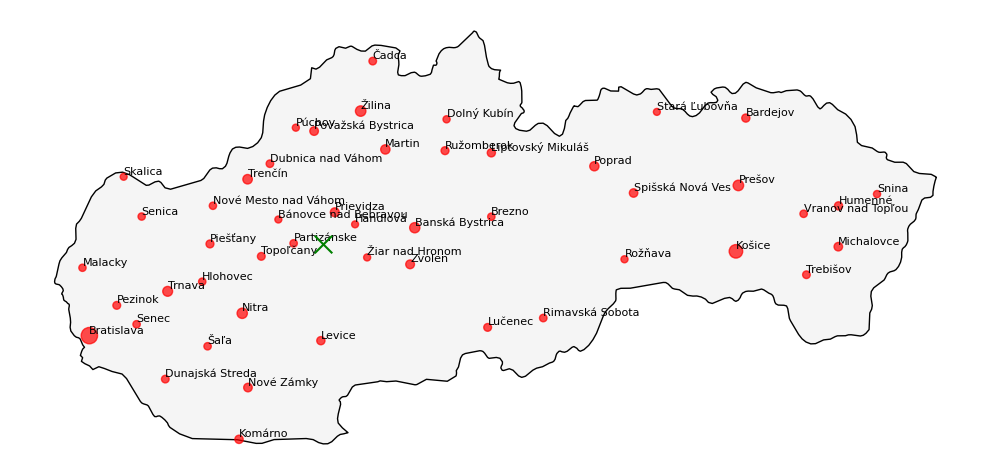

In [3]:
# x0 = np.array([
#     (DF_MESTA.geometry.x * DF_MESTA['Weight']).sum(),
#     (DF_MESTA.geometry.y * DF_MESTA['Weight']).sum()
# ])

# x0_1 = (DF_MESTA.geometry.x * DF_MESTA['Weight']).sum()
# x0_2 = (DF_MESTA.geometry.y * DF_MESTA['Weight']).sum()


# xk_1 = x0_1
# xk_2 = x0_2

# while True:
#     s1 = 0
#     s2 = 0
    
#     for i in range(M):
#         mesto = DF_MESTA.iloc[i]

#         di = ( (xk_1 - DF_MESTA.geometry.x)**2 + (xk_2 - DF_MESTA.geometry.y)**2 )**0.5

#         h_1 = mesto['Weight'] * mesto.geometry.x
#         h_2 = mesto['Weight'] * mesto.geometry.y


WC = WEIGHTS * COORDS
EPS = 10**-6

x0 = np.sum(WC, axis=0)
xk = x0.copy()
i = 0

while True:
    d = np.linalg.norm(xk-COORDS, axis=1)[:, None]

    # print(WC / d)
    xkk = np.sum(WC/d, axis=0) / np.sum(WEIGHTS / d)
    i += 1

    if np.linalg.norm(xkk - xk) < EPS:
        xk = xkk
        break

    xk = xkk

    

print(f'Finished in {i} iterations, found: {xk}')
plot_slovakia(xk)

# a = np.array([
#     [2**0.5,2**0.5],
#     [5,5]
# ])
# np.linalg.norm(a, axis=1)

# Uloha e)

Finished in 23 iterations, found [ -461684.21540438 -1236578.84279756]


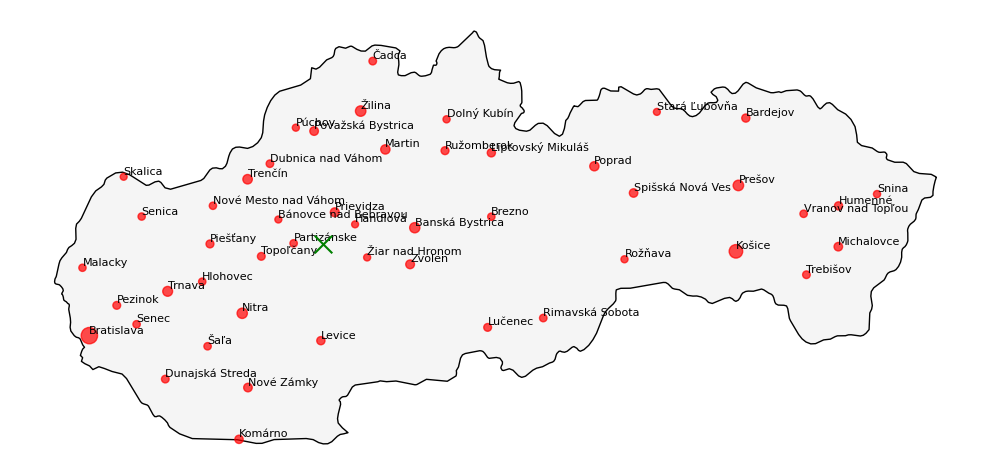

Step 10 finished in 100001 iterations, found [ -461344.18742769 -1236449.64627078]
Step 20 finished in 100001 iterations, found [ -461677.0085052 -1236576.0940274]
Step 40 finished in 72316 iterations, found [ -461684.18018992 -1236578.82936794]
Step 80 finished in 36155 iterations, found [ -461684.18017954 -1236578.82936398]
Step 160 finished in 18075 iterations, found [ -461684.18023357 -1236578.82938459]
Step 320 finished in 9035 iterations, found [ -461684.18034179 -1236578.82942586]
Step 640 finished in 4515 iterations, found [ -461684.18055885 -1236578.82950864]
Step 1280 finished in 2255 iterations, found [ -461684.1809955  -1236578.82967516]
Step 2560 finished in 1125 iterations, found [ -461684.18187887 -1236578.83001205]
Step 5120 finished in 560 iterations, found [ -461684.18368624 -1236578.83070132]
Step 10240 finished in 277 iterations, found [ -461684.18268322 -1236578.83031882]
Step 20480 finished in 136 iterations, found [ -461684.19099311 -1236578.83348792]
Step 40960 

In [4]:
def gradient_basic(step, eps, max_itrs):
    WC = WEIGHTS * COORDS
    x0 = np.sum(WC, axis=0)
    xk = x0.copy()

    i = 0
    while True:
        d = np.linalg.norm(xk - COORDS, axis=1)[:, None]
        g = np.sum(WEIGHTS * (xk - COORDS) / d, axis=0)

        if np.linalg.norm(g) < eps or i > max_itrs:
            break

        xk = xk - g*step
        # print(g)
        i += 1
    
    return xk, i

x, i = gradient_basic(100_000, 10**-6, 100_000)
print(f'Finished in {i} iterations, found {x}')
plot_slovakia(x)

step = 10
while step < 10**7:
    x, i = gradient_basic(step, 10**-6, 100_000)
    print(f'Step {step} finished in {i} iterations, found {x}')
    step *= 2




# Uloha f)


In [ ]:
W = WEIGHTS.reshape(-1)

# ucelova funkcia
def objective(x):
    distances = np.linalg.norm(COORDS - x, axis=1)
    return np.sum(W * distances)


# gradient ucelovej funkcie
def gradient(x):
    distances = np.linalg.norm(x - COORDS, axis=1)

    distances = np.maximum(distances, 1e-12)

    g = np.sum(W[:, None] * (x - COORDS) / distances[:, None], axis=0)
    return g


# startovaci bod rovnaky ako v casti d) a e)
def starting_point():
    return np.sum(W[:, None] * COORDS, axis=0)


# f1) gradientna metoda s backtrackingom
def gradient_backtracking(eps=1e-6, max_itrs=10_0000, alpha=0.01, delta=0.5):
    xk = starting_point()
    iterations = []
    i = 0

    while i < max_itrs:
        iterations.append(xk)
        g = gradient(xk)

        if np.linalg.norm(g) < eps:
            break

        lambda_k = 300_000
        current_value = objective(xk)

        while objective(xk - lambda_k * g) > current_value - alpha * lambda_k * np.linalg.norm(g)**2:
            lambda_k *= delta

        xk = xk - lambda_k * g

        i += 1
    return xk, i, iterations

def gradient_optimal_step(step_bound = 300_000, eps=1e-6, max_itrs=100000):
    xk = starting_point()
    iterations = []
    i = 0

    while i < max_itrs:
        iterations.append(xk)
        g = gradient(xk)

        if np.linalg.norm(g) < eps:
            break

        phi = lambda l: objective(xk - l * g)

        result = minimize_scalar(
            phi,
            bounds=(0, step_bound),
            method="bounded"
        )

        lambda_k = result.x

        xk = xk - lambda_k * g


        i += 1

    return xk, i, iterations

Gradientna metoda s backtrackingom
Najdeny bod: [ -461684.41231733 -1236578.85342091]
Pocet iteracii: 15


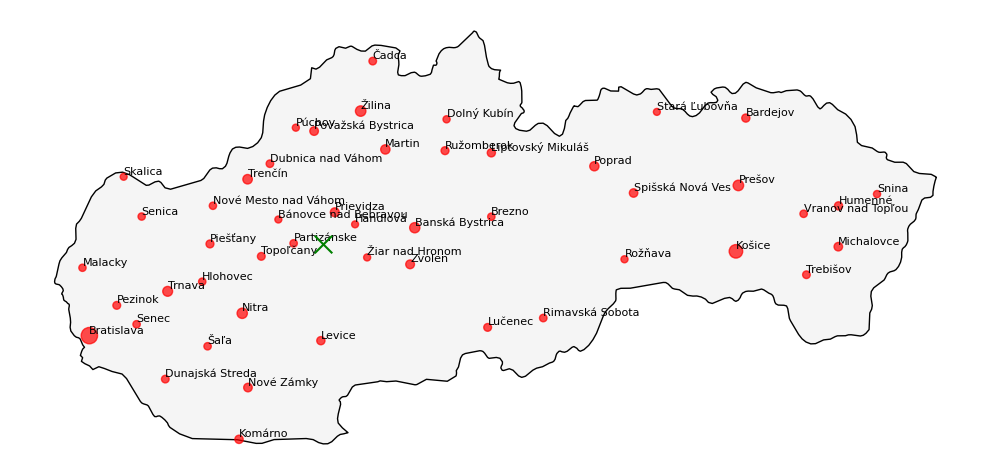

In [ ]:
x_backtracking, it_backtracking, iterations_backtracking = gradient_backtracking()

print("Gradientna metoda s backtrackingom")
print("Najdeny bod:", x_backtracking)
print("Pocet iteracii:", it_backtracking)
plot_slovakia(point=x_backtracking)

Gradientna metoda s optimalnym krokom
Najdeny bod: [ -461684.30348828 -1236578.92758915]
Pocet iteracii: 14


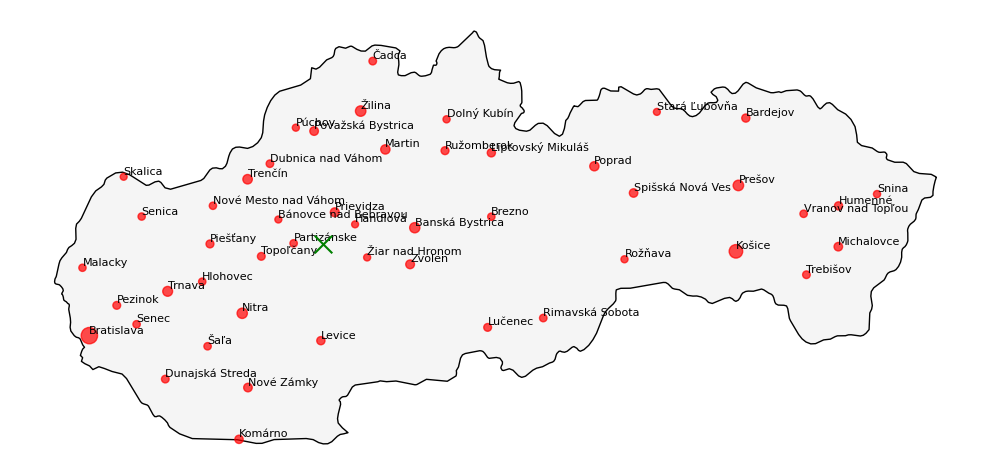

In [ ]:
x_optimal, it_optimal, iterations_optimal = gradient_optimal_step()

print("Gradientna metoda s optimalnym krokom")
print("Najdeny bod:", x_optimal)
print("Pocet iteracii:", it_optimal)
plot_slovakia(point=x_optimal)


# Uloha g)



In [ ]:
def golden_section(f, a, b, tol=1e-6):

    phi = (1 + np.sqrt(5))/2
    rho = phi - 1

    c1 = rho*a + (1 - rho)*b
    f1 = f(c1)
    c2 = (1 - rho)*a + rho*b
    f2 = f(c2)

    while abs(b - a) > tol:

        if f1 < f2:
            b = c2  # minimum je vlavo od bodu c2
            c2 = c1
            f2 = f1
            c1 = rho*a + (1 - rho)*b
            f1 = f(c1)
        else:
            a = c1  # minimum je vpravo od bodu c1
            c1 = c2
            f1 = f2
            c2 = (1 - rho)*a + rho*b
            f2 = f(c2)

    return (a+b)/2  # interval neurcitosti


def cauchy_method(f, x0, a=1e-2, b=0.2, epsilon=1e-5, max_iters=10_000):
    x = x0.copy()
    k = 0

    x_iter = []
    x_iter.append(x.copy())

    while k < max_iters:
        # smer najvacsieho spadu
        grad = -grad_f_eval(f, x)

        # kontrola podmienky optimality
        if np.linalg.norm(grad) <= epsilon:
            break

        # hladanie optimalnej dlzky kroku pomocou metody zlateho rezu
        def f_new(z):
            return f.subs({x1: (x + z*grad)[0], x2: (x + z*grad)[1]}) # zuzenie funkcie f na priamku danu bodom x a smerom grad

        lambda_k = golden_section(f_new, a, b)

        # iteracny proces
        x += lambda_k * grad
        k += 1

        x_iter.append(x.copy())

    print(f"Pocet iteracii: {k}")

    return (x, x_iter)

# Uloha h)

In [22]:
# Uloha H - nacitanie rozsirenych dat
DF_MESTA_EXT = pd.read_csv(
    'data/slovensko_extended.csv',
    sep=','
)

M_EXT = len(DF_MESTA_EXT)
SUCET_POPULACIE_EXT = DF_MESTA_EXT['Population'].sum()
DF_MESTA_EXT['Weight'] = DF_MESTA_EXT['Population'] / SUCET_POPULACIE_EXT

DF_MESTA_EXT['geometry'] = [
    Point(xy) for xy in zip(DF_MESTA_EXT['Longitude'], DF_MESTA_EXT['Latitude'])
]

DF_MESTA_EXT = gpd.GeoDataFrame(
    DF_MESTA_EXT,
    geometry='geometry',
    crs='EPSG:4326'
)
DF_MESTA_EXT = DF_MESTA_EXT.to_crs(epsg=5514)

COORDS_EXT = np.column_stack([
    DF_MESTA_EXT.geometry.x,
    DF_MESTA_EXT.geometry.y,
])

WEIGHTS_EXT = DF_MESTA_EXT['Weight'].to_numpy()[:, None]

print(f'Nacitanych miest: {M_EXT}')
DF_MESTA_EXT.head()


Nacitanych miest: 100


,City,Longitude,Latitude,Population,Weight,geometry
0,Bratislava,17.107362,48.147722,479389,0.181035,POINT (-573721.533 -1280416.687)
1,Košice,21.250169,48.716782,223678,0.084469,POINT (-263382.1 -1239958.625)
2,Prešov,21.246051,49.001436,81702,0.030854,POINT (-262204.075 -1208325.891)
3,Žilina,18.736655,49.218791,80257,0.030308,POINT (-443502.874 -1172635.263)
4,Nitra,18.076839,48.306085,75945,0.028680,POINT (-500350.884 -1269696.866)


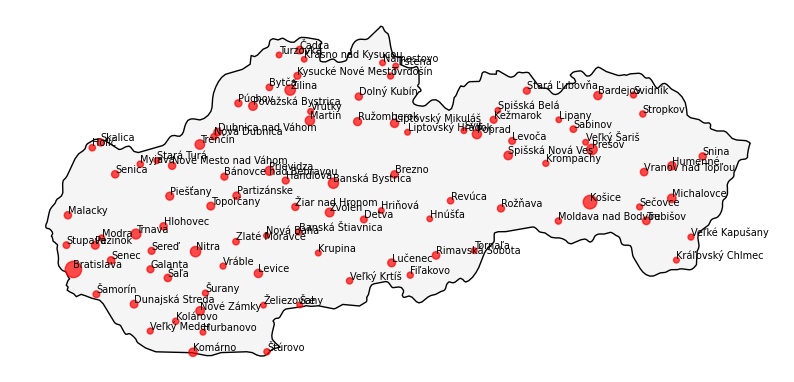

In [23]:
def plot_slovakia_extended(point=None):
    slovakia_ext = gpd.read_file(
        "data/ne_10m_admin_0_countries.zip"
    )

    slovakia_ext = slovakia_ext[slovakia_ext["ISO_A3"] == "SVK"]
    slovakia_ext = slovakia_ext.to_crs(epsg=5514)

    fig, ax = plt.subplots(figsize=(10, 8))

    slovakia_ext.plot(
        ax=ax,
        color='whitesmoke',
        edgecolor='black'
    )

    DF_MESTA_EXT.plot(
        ax=ax,
        color='red',
        markersize=np.sqrt(DF_MESTA_EXT['Population']) / 5,
        alpha=0.7
    )

    if point is not None:
        ax.scatter(
            point[0], point[1],
            s=160,
            color='green',
            marker='x',
            zorder=5
        )

    for x, y, city in zip(
        DF_MESTA_EXT.geometry.x,
        DF_MESTA_EXT.geometry.y,
        DF_MESTA_EXT['City']
    ):
        ax.text(x, y, city, fontsize=7, ha='left', va='bottom')

    ax.set_axis_off()
    plt.show()

plot_slovakia_extended()


## Cast D s rozsirenym datasetom

Weiszfeld finished in 54 iterations, found: [ -452620.62229796 -1236458.79969435]


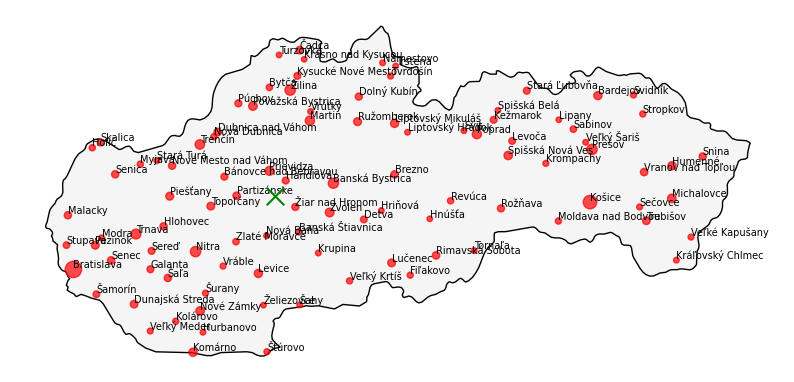

In [24]:
WC_EXT = WEIGHTS_EXT * COORDS_EXT
EPS = 10**-6

x0_ext = np.sum(WC_EXT, axis=0)
xk_ext = x0_ext.copy()
i_ext = 0

while True:
    d_ext = np.linalg.norm(xk_ext - COORDS_EXT, axis=1)[:, None]

    # Ochrana proti deleniu nulou, ak by xk_ext presne padol do niektoreho mesta
    d_ext = np.where(d_ext == 0, 10**-12, d_ext)

    xkk_ext = np.sum(WC_EXT / d_ext, axis=0) / np.sum(WEIGHTS_EXT / d_ext)
    i_ext += 1

    if np.linalg.norm(xkk_ext - xk_ext) < EPS:
        xk_ext = xkk_ext
        break

    xk_ext = xkk_ext

print(f'Weiszfeld finished in {i_ext} iterations, found: {xk_ext}')
plot_slovakia_extended(xk_ext)

## Cast E s rozsirenym datasetom

Gradient finished in 18 iterations, found: [ -452620.46643757 -1236458.75113494]


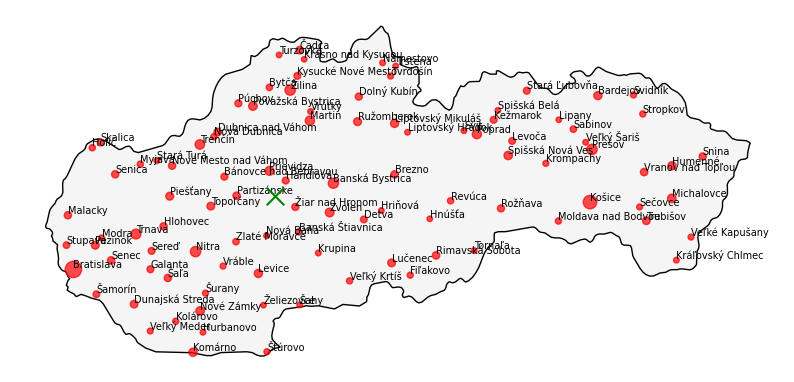

Step 10 finished in 100001 iterations, found: [ -452484.94016057 -1236419.34832074]
Step 20 finished in 100001 iterations, found: [ -452619.37882915 -1236458.41283018]
Step 40 finished in 59648 iterations, found: [ -452620.41852058 -1236458.7362252 ]
Step 80 finished in 29821 iterations, found: [ -452620.41850807 -1236458.73622128]
Step 160 finished in 14908 iterations, found: [ -452620.41855948 -1236458.73623724]
Step 320 finished in 7451 iterations, found: [ -452620.41850966 -1236458.73622163]
Step 640 finished in 3723 iterations, found: [ -452620.41871644 -1236458.73628583]
Step 1280 finished in 1859 iterations, found: [ -452620.41913294 -1236458.73641514]
Step 2560 finished in 927 iterations, found: [ -452620.41997776 -1236458.73667747]
Step 5120 finished in 461 iterations, found: [ -452620.42171506 -1236458.73721706]
Step 10240 finished in 228 iterations, found: [ -452620.42538278 -1236458.73835677]
Step 20480 finished in 111 iterations, found: [ -452620.42374316 -1236458.73784205

In [25]:
def gradient_basic_extended(step, eps, max_itrs):
    WC_EXT = WEIGHTS_EXT * COORDS_EXT
    x0_ext = np.sum(WC_EXT, axis=0)
    xk_ext = x0_ext.copy()

    i_ext = 0
    while True:
        d_ext = np.linalg.norm(xk_ext - COORDS_EXT, axis=1)[:, None]

        # Ochrana proti deleniu nulou
        d_ext = np.where(d_ext == 0, 10**-12, d_ext)

        g_ext = np.sum(WEIGHTS_EXT * (xk_ext - COORDS_EXT) / d_ext, axis=0)

        if np.linalg.norm(g_ext) < eps or i_ext > max_itrs:
            break

        xk_ext = xk_ext - g_ext * step
        i_ext += 1

    return xk_ext, i_ext

x_ext, i_ext = gradient_basic_extended(100_000, 10**-6, 100_000)
print(f'Gradient finished in {i_ext} iterations, found: {x_ext}')
plot_slovakia_extended(x_ext)

step = 10
while step < 10**7:
    x_ext, i_ext = gradient_basic_extended(step, 10**-6, 100_000)
    print(f'Step {step} finished in {i_ext} iterations, found: {x_ext}')
    step *= 2